In [27]:
import numpy as np
import scipy #Library for signal analysis
import matplotlib.pyplot as plt #Plot
import numpy as np #Operations
import cv2 #Read images and do operations
import IPython.display as ipd
import numpy.random #For generating noise
import copy

from copy import deepcopy

from numpy import linalg

from scipy import signal
from scipy.io import wavfile #Read wavfiles
from scipy.signal import welch,stft,istft #Get power density estimated, short fourier transform

audio_file = 'music.wav'

def read_file_PROPERLY(wavfile_name):
    samplerate_music, data_music = wavfile.read(wavfile_name) #Read the file
    data_music=data_music.astype(np.double)/2**15
    return samplerate_music,data_music

fs, data = read_file_PROPERLY(audio_file)#wavfile.read(audio_file)

Ls = len(data)

print('Setting up the frame parameters\n')


inputSDR = 7


wtype = 'hann'
w = 8192
a = int(w / 4)
M = 2*w

shrinkage = 'EW'
print('Setting up shrinkage operator: %s\n', shrinkage)

verbose = True


Setting up the frame parameters

Setting up shrinkage operator: %s
 EW


In [28]:
data

array([ 0.00549316, -0.0045166 , -0.01220703, ..., -0.04577637,
        0.00592041,  0.0428772 ])

In [29]:
ipd.Audio(data, rate=fs)

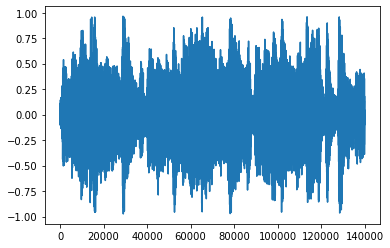

In [30]:
plt.plot(data)

In [31]:
def clip_audio(data, thresh):
    data = data.copy()
    masks = {}
    masks['Mh'] = (data > thresh)
    masks['Ml'] = (data < -thresh)
    masks['Mr'] = (data > thresh) | (data < -thresh)
    data[masks['Mr']] = thresh
    return data, masks

In [65]:
theta = 0.2#15000

data_clipped, masks = clip_audio(data, theta)

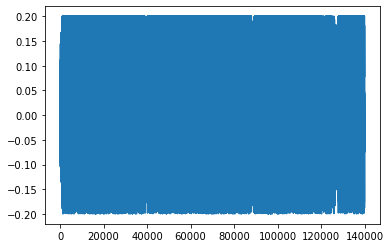

In [66]:
plt.plot(data_clipped)

In [67]:
ipd.Audio(data_clipped, rate=fs)

In [68]:
data_r = np.zeros((Ls,))
data_r[masks['Mr']] = data_clipped[masks['Mr']]

In [69]:
data_c = np.zeros(Ls)
data_c[masks['Mh']] = theta;
data_c[masks['Ml']] = -theta;

In [70]:
from ltfatpy.gabor.gabwin import gabwin
from ltfatpy.gabor.gabtight import gabtight
from ltfatpy.gabor.dgtreal import dgtreal
from ltfatpy.gabor.idgtreal import idgtreal

In [71]:

g = gabtight({'name': 'hann', 'M':w}, a, M)

g = (g, {})

data_clipped_float = data_clipped.astype('float64')

G_clip = dgtreal(data_clipped_float, g[0], a, M)
print(len(G_clip))
[nf,nt] = G_clip[0].shape


def analysis(x):
    return dgtreal(x,g[0],a,M)[0]
    
def synthesis(x):
    return idgtreal(x,g[0],a,M,Ls)[0]

3


In [72]:
g

(array([0.00637888, 0.00637888, 0.00637888, ..., 0.00637887, 0.00637888,
        0.00637888]),
 {})

In [73]:
# if shrinkage == 'L':
#     shrink = {'type':'l', 'lambda':1e-4, 'mu':1, 'glabel':'time','neigh':1, 'center':[1, 1], 'expo':1,'orth':0}
# elif shrinkage == 'WGL':
#     shrink = {'type':'l', 'lambda':1e-4, 'mu':1, 'glabel':'time','neigh':np.ones((3,7)), 'center':[2,4], 'expo':1,'orth':0}
# elif shrinkage == 'EW':
# shrink = {'type': 'l', 'lambda': 1e-4, 'mu': 1, 'glabel': 'time','neigh': 1, 'center': [1, 1], 'expo': 2,'orth':0}
# elif shrinkage == 'PEW':
shrink = {'type': 'l', 'lambda': 1e-4, 'mu': 1, 'glabel': 'time','neigh': np.ones((3,7)), 'center': [2,4], 'expo': 2,'orth':0}
# else:
#     error('Invalid shrinkage operator!')

In [74]:
# def maximum(x):
#     return max(0,x)

# def lasso_threshold(coeff,lambd):
#     first = lambd/abs(coeff)
#     maximun_v = np.vectorize(maximum)
#     second = maximun_v(first)
#     second=second.astype('complex128')
#     return second

In [75]:
kok = np.arange(0,16).reshape((4,-1))
kok, kok[0:3, 0:3]

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15]]),
 array([[ 0,  1,  2],
        [ 4,  5,  6],
        [ 8,  9, 10]]))

In [76]:
import math 

def sdr (u, v):

    sdr_val = 20*np.log10(np.linalg.norm(u)/np.linalg.norm(u-v))

    return sdr_val

def l_threshfunc(W, lama):
    threshfunc = lama/W
    return threshfunc
    
from scipy.signal import convolve2d

def conv2(x, y, mode='same'):
    return convolve2d(x, y, mode=mode)#np.rot90(convolve2d(np.rot90(x, 2), np.rot90(y, 2), mode=mode), 2)

def pers_weights(G, neigh, center):
    M, N = G.shape
    MM, NN = neigh.shape
#     print(MM, NN)
    c1 = center[0]
    c2 = center[1]
    cc1 = math.ceil(MM/2) 
    cc2 = math.ceil(NN/2) #% take actual centers of neighborhood
    neigh = neigh/np.linalg.norm(neigh[:],1) #% normalize neighborhood weights

#     % check neighborhood - center point relations
    if center[0] > MM:
        print('This cannot be right... Check your center point.')
        return
    elif center[1] > NN:
        print('This cannot be right... Check your center point.')
        return
    

    X2 = np.zeros((M+MM-1, N+NN-1)) #% make larger matrix with mirrowed borders:

    X2[c1: M+c1, c2:N+c2] = np.power(np.abs(G), 2) #% put x in the middle of x2

    X2[:, :c2] =  np.fliplr(X2[:, c2:2*(c2)]) #% left border
    
    X2[:, N+c2:] = np.fliplr(X2[:, N - NN +2*c2: N+c2 -1]) #% right border

    X2[:c1, :] = np.flipud(X2[c1:2*(c1), :]) #% upper border

    X2[M+c1:, :] = np.flipud(X2[M-MM + 2*c1: M+c1, :])# % lower border


    X2 = conv2(X2, neigh, 'same')

    W = X2[cc1: M + cc1 , cc2: N + cc2] #% resize matrix 
    W = np.sqrt(W) #% should be included for WGL!
    return W


def gen_thresh(G, shrink):
    # % computation of persistence weights
    W = pers_weights(G, shrink['neigh'], shrink['center'])

    # % computation of threshold function value
    TF = l_threshfunc(W, shrink['lambda'])#lasso_threshold(W, shrink['lambda'])#

    # % compute shrinkage
    TF[np.isinf(TF)] = 0
    Gs = 1 - np.power(TF, shrink['expo'])
    GGs = Gs*(Gs>0)
    
    
#     print(W.shape, Gs.shape, TF.shape, GGs.shape)
    Gs = G*GGs

    return Gs

In [77]:
from tqdm import tqdm
Gdeclip = np.zeros((nf,nt), dtype=np.complex128)
GdeclipZ = Gdeclip

number_lambdas = 5
inner_iterations = 500
delta = 1e-4
iter_cnt = 0

init_sdr = sdr(data, data_clipped)

# dSDR_process = np.empty(number_lambdas*inner_iterations)
# dSDR_process[:] = np.NaN
data_rec = data_clipped

for lamba in tqdm(np.logspace(-1,-4,number_lambdas)):
    shrink['lambda'] = lamba
    for k in range(inner_iterations):

        data_rec_old = data_rec.copy()
        iter_cnt = iter_cnt + 1

#         % forward step
        GdeclipOLD = Gdeclip
    
#         print(GdeclipZ)

        xdeclipZ = synthesis(GdeclipZ)
        
        if np.isnan(np.min(xdeclipZ)):
            raise Exception('np.isnan(np.min(xdeclipZ))')

        r1 = np.zeros(Ls)
#         print(xdeclipZ[masks['Mr']])
        r1[masks['Mr']] = data_r[masks['Mr']] - xdeclipZ[masks['Mr']]

        grad1 = -analysis(r1)

        r2 = np.zeros(Ls)
        r2[masks['Mh']] = data_c[masks['Mh']] - xdeclipZ[masks['Mh']]
        r2[masks['Ml']] = data_c[masks['Ml']] - xdeclipZ[masks['Ml']]

        r2[np.abs(xdeclipZ)>theta] = 0
        grad2 = -analysis(r2)


        GdeclipZ = GdeclipZ - grad1 - grad2
        
        if np.isnan(np.min(GdeclipZ)):
            raise Exception('GdeclipZ')
            

#         % thresholding step
        Gdeclip = gen_thresh(GdeclipZ, shrink) #lasso_threshold(GdeclipZ, lamba)#
        
        if np.isnan(np.min(GdeclipZ)):
            raise Exception('Gdeclip')

#         % relaxation step
        GdeclipZ = Gdeclip + (k-1)/(k+5) * (Gdeclip - GdeclipOLD)



        data_rec = synthesis(Gdeclip)
        
        if np.isnan(np.min(data_rec)):
            raise Exception('Gdeclip')
#         print(data_rec)
        dif = np.linalg.norm(data_rec_old - data_rec)
        if dif  < delta:
            break
        


        if verbose:
            sdr_rec = sdr(data, data_rec)
            print(sdr_rec, init_sdr, dif)
        

    


  0%|          | 0/5 [00:00<?, ?it/s]

2.7165451218753214 -0.5131432309828504 47.593809502629185
1.6503165937472186 -0.5131432309828504 27.67778215106359
1.805632793035413 -0.5131432309828504 8.082651328728103
1.5724303363190337 -0.5131432309828504 4.612330917681517
1.5725328167709072 -0.5131432309828504 3.6554049895052456
1.4214922882506353 -0.5131432309828504 2.8274859882695327
1.439626844639569 -0.5131432309828504 2.311994884325207
1.3209819737642226 -0.5131432309828504 1.956777224810432
1.3779477082187628 -0.5131432309828504 1.8334041922400215
1.2550082461371344 -0.5131432309828504 1.9007797425875919
1.365406911866025 -0.5131432309828504 2.237828327961657
1.1935868905511375 -0.5131432309828504 2.7955952135244773
1.3971989307102701 -0.5131432309828504 3.8016058473565906
1.0999540667464827 -0.5131432309828504 5.315870398507684
1.4853019697197607 -0.5131432309828504 7.317592091548159
0.9431136070373569 -0.5131432309828504 10.198177031692676
1.3590039041321798 -0.5131432309828504 8.971551576756383
0.9181254434303282 -0.5131

0.9702923030904286 -0.5131432309828504 12.494123102674008
0.9550023199407359 -0.5131432309828504 12.669935922709167
0.9388103730155013 -0.5131432309828504 12.3063469995723
0.9958330223656121 -0.5131432309828504 11.973232172200117
0.9840242646740311 -0.5131432309828504 12.375057407271324
0.9690788928141535 -0.5131432309828504 11.873786355053957
1.0072588933877888 -0.5131432309828504 11.7595286693435
1.0680152473387217 -0.5131432309828504 12.658570458416849
0.8843113790410863 -0.5131432309828504 12.749017884563887
0.9948923586578456 -0.5131432309828504 12.02799529627673
0.9427713643751773 -0.5131432309828504 12.691777220707682
1.0084886568308513 -0.5131432309828504 11.891699749280852
0.9908312032637359 -0.5131432309828504 12.687528525969489
0.9669899733441429 -0.5131432309828504 13.022312011738327
0.8911543324606087 -0.5131432309828504 12.316976998742307
1.0418686800219827 -0.5131432309828504 12.5891319389886
0.9038728314734394 -0.5131432309828504 12.881348875215204
0.9972806330205994 -0

  0%|          | 0/5 [00:21<?, ?it/s]

0.9180952119544694 -0.5131432309828504 12.211697599546623


KeyboardInterrupt: 

In [78]:
ipd.Audio(data_rec, rate=fs)

In [ ]:
plt.plot(data_rec)

In [ ]:
plt.plot(data)